# Log2FC comparison of the AXL and other genes

Compares the pyDESeq2 results of AXL vs GFP with the other perturbations (ERBB2 sham/MI, hOSM, mOSM, mLIF, IGF1) at the level of all genes:

1. **Correlation matrix of the contrasts**: Spearman correlation of the DESeq2 Wald `stat` across genes, on (a) all genes shared by every contrast and (b) only genes that are DEGs in at least one contrast.
2. **Direction-aware DEG overlap**: for every pair of contrasts, genes are classified as up/up, down/down, up/down, down/up. Reported per pair:
   - *directional Jaccard* = concordant DEGs / DEGs in either contrast (0 = no shared same-direction DEGs, 1 = identical DEG sets with identical directions);
   - *direction agreement* = (concordant - discordant) / (concordant + discordant) among genes that are DEGs in both (+1 = all shared DEGs move the same way, -1 = all opposite);
   - one-sided Fisher's exact tests for over-representation of shared up and shared down DEGs.

All tables are translated to human symbols (HCOP). Only genes tested in both contrasts of a pair are used for that pair.

**Caveat**: the datasets come from different systems (in-vitro neonatal mouse CMs for AXL and OSM/LIF, in-vivo whole hearts for ERBB2, neonatal rat CMs for IGF1) and time points. Differences can reflect the system rather than the pathway; similarity is the more robust signal. hOSM, mOSM and mLIF share a control group and an experiment, so they are expected to cluster together.

In [1]:
import os
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import liana as li
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import fisher_exact

## Configuration

In [2]:
root_dir = '/mnt/sds-hd/sd22b002/projects/ines/axl_networks'
figures_dir = f'{root_dir}/figures'
results_dir = f'{root_dir}/results/contrast_comparison'
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# label -> (DESeq2 results table, species of its gene symbols)
# all contrasts must be oriented as perturbation vs control
datasets = {
    'AXL vs GFP': (f'{root_dir}/data/CMV_GFP_4_GFP_new copy.csv', 'mouse'),
    'ERBB2 OE vs WT (sham)': (f'{root_dir}/results/erbb2/pydeseq2/GSE144391_ERBB2_sham_deseq2.csv', 'mouse'),
    'ERBB2 OE vs WT (MI)': (f'{root_dir}/results/erbb2/pydeseq2/GSE144391_ERBB2_MI_deseq2.csv', 'mouse'),
    'hOSM vs Control': (f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_hosm_vs_control_deseq2.csv', 'mouse'),
    'mOSM vs Control': (f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_mosm_vs_control_deseq2.csv', 'mouse'),
    'mLIF vs Control': (f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_lif_vs_control_deseq2.csv', 'mouse'),
    'IGF1 vs Control': (f'{root_dir}/results/igf1/pydeseq2/GSE153763_IGF1_IGF1_vs_Control_deseq2.csv', 'rat'),
}
reference = 'AXL vs GFP'   # contrast compared against every other one in section 5

gene_col, lfc_col, stat_col, padj_col = 'Gene.name', 'log2FoldChange', 'stat', 'padj'

hcop_min_evidence = 3      # same as the CORNETO notebooks

padj_threshold = 0.05
lfc_threshold = 0          # minimum |log2FC| to call a DEG (0 = padj only, as in the manuscript)

corr_method = 'spearman'
corr_value = stat_col      # value correlated between contrasts (stat_col or lfc_col)

## Load the results tables and translate to human symbols

In [3]:
def load_orthologs(species):
    """Series: mouse/rat symbol -> human symbol, keeping only human symbols with a single source gene."""
    if species == 'mouse':
        m = li.rs.get_hcop_orthologs(
            url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
            columns=['human_symbol', 'mouse_symbol'],
            min_evidence=hcop_min_evidence,
        )
    elif species == 'rat':
        m = pd.read_csv(f'{root_dir}/reference/human_rat_hcop_fifteen_column.txt', sep='\t')
        m = m[m['support'].str.split(',').str.len() >= hcop_min_evidence]
        m = m[['human_symbol', 'rat_symbol']]
    else:
        raise ValueError(f'Unknown species: {species}')

    m = m.rename(columns={f'{species}_symbol': 'source_symbol'})
    # remove genes without an ortholog in human
    m = m[(m['human_symbol'] != '-') & (m['source_symbol'] != '-')].drop_duplicates()
    # keep unique human genes (remove all duplicated human symbols to keep 1:1 orthologs)
    m = m[~m.duplicated(subset='human_symbol', keep=False)]
    return m.set_index('source_symbol')['human_symbol']

orthologs = {sp: load_orthologs(sp) for sp in {sp for _, sp in datasets.values()}}

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/liana/resource/_orthology.py:278: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [4]:
tables = {}
for label, (path, species) in datasets.items():
    if not os.path.exists(path):
        print(f'WARNING: {label}: file not found, skipped ({path})')
        continue
    df = pd.read_csv(path)
    missing_cols = {gene_col, lfc_col, stat_col, padj_col} - set(df.columns)
    if missing_cols:
        raise ValueError(f'{label}: missing columns {missing_cols}; found {list(df.columns)}')
    df = df.drop_duplicates(gene_col).set_index(gene_col)[[lfc_col, stat_col, padj_col]]

    # translate to human symbols (inner join: genes without a 1:1 ortholog are dropped)
    human = df.join(orthologs[species].rename('human_symbol'), how='inner')
    tables[label] = human.set_index('human_symbol')
    print(f'{label} ({species}): {len(df)} genes, {len(tables[label])} with a human ortholog')

labels = list(tables)
assert reference in labels, f'Reference contrast {reference!r} was not loaded'

# wide tables: human gene x contrast (NaN = gene not in that table)
lfc_df = pd.DataFrame({l: t[lfc_col] for l, t in tables.items()})
stat_df = pd.DataFrame({l: t[stat_col] for l, t in tables.items()})
padj_df = pd.DataFrame({l: t[padj_col] for l, t in tables.items()})

# DEG calls: +1 up, -1 down, 0 tested but not a DEG, NaN not tested (no stat)
is_deg = (padj_df < padj_threshold) & (lfc_df.abs() >= lfc_threshold)
deg_direction = np.sign(lfc_df).where(is_deg, 0).where(stat_df.notna())

summary = pd.DataFrame({
    'genes_tested': stat_df.notna().sum(),
    'DEGs_up': (deg_direction == 1).sum(),
    'DEGs_down': (deg_direction == -1).sum(),
})
summary.to_csv(f'{results_dir}/deg_summary.csv')
summary

AXL vs GFP (mouse): 22599 genes, 14548 with a human ortholog
ERBB2 OE vs WT (sham) (mouse): 23854 genes, 14509 with a human ortholog
ERBB2 OE vs WT (MI) (mouse): 23854 genes, 14509 with a human ortholog
hOSM vs Control (mouse): 19157 genes, 12728 with a human ortholog
mOSM vs Control (mouse): 19157 genes, 12728 with a human ortholog
mLIF vs Control (mouse): 19157 genes, 12728 with a human ortholog
IGF1 vs Control (rat): 17127 genes, 13020 with a human ortholog


,genes_tested,DEGs_up,DEGs_down
AXL vs GFP,14548,3562,3080
ERBB2 OE vs WT (sham),14509,3665,3086
ERBB2 OE vs WT (MI),14509,2474,2123
hOSM vs Control,12728,1077,791
mOSM vs Control,12728,780,457
mLIF vs Control,12728,107,23
IGF1 vs Control,13020,2812,2236


## Plotting helpers

In [5]:
def slug(text):
    return re.sub(r'[^A-Za-z0-9]+', '_', text).strip('_')


def clustered_order(sim):
    """Order of rows/columns from average-linkage clustering of a similarity matrix (distance = 1 - similarity)."""
    dist = squareform((1 - sim.values).clip(min=0), checks=False)
    return sim.index[leaves_list(linkage(dist, method='average'))]


def plot_matrix_heatmap(mat, title, fname, vmin=-1, vmax=1, cmap='RdBu_r', fmt='{:.2f}', cbar_label='', order=None):
    """Contrast x contrast heatmap with the value written in each cell."""
    if order is not None:
        mat = mat.loc[order, order]
    n = len(mat)
    fig, ax = plt.subplots(figsize=(0.55 * n + 2.5, 0.55 * n + 1.8))
    im = ax.imshow(mat.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax)
    for i in range(n):
        for j in range(n):
            v = mat.iat[i, j]
            if pd.isna(v):
                continue
            r, g, b, _ = im.cmap(im.norm(v))
            color = 'white' if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else 'black'
            ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=7, color=color)
    ax.set_xticks(range(n))
    ax.set_xticklabels(mat.columns, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(mat.index, fontsize=8)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(f'{figures_dir}/{fname}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{figures_dir}/{fname}.pdf', bbox_inches='tight')
    plt.show()

## Correlation matrix of the contrasts

### All genes shared by every contrast

11323 genes tested in every contrast


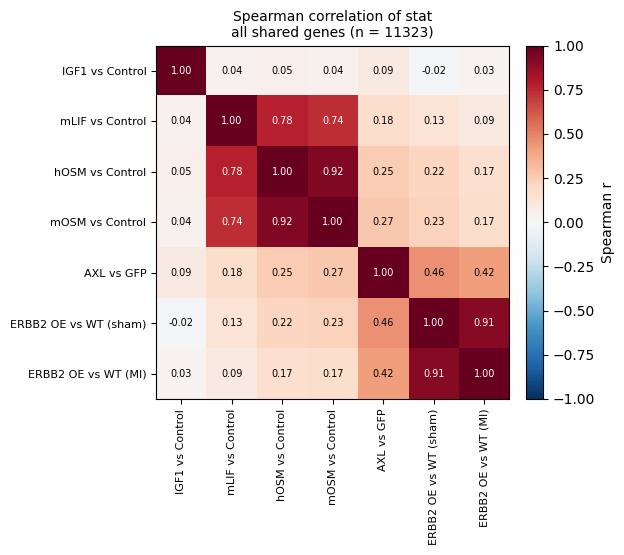

In [6]:
value_df = stat_df if corr_value == stat_col else lfc_df
shared_genes = value_df.dropna().index
print(f'{len(shared_genes)} genes tested in every contrast')

corr_all = value_df.loc[shared_genes].corr(method=corr_method)
corr_all.to_csv(f'{results_dir}/correlation_{corr_method}_{corr_value}_all_shared_genes.csv')
contrast_order = clustered_order(corr_all)   # reused for every matrix below

plot_matrix_heatmap(
    corr_all,
    title=f'{corr_method.capitalize()} correlation of {corr_value}\nall shared genes (n = {len(shared_genes)})',
    fname=f'correlation_{corr_method}_{corr_value}_all_shared_genes',
    cbar_label=f'{corr_method.capitalize()} r',
    order=contrast_order,
)

### Only genes that are DEGs in at least one contrast
Note that AXL has by far the most DEGs, so this gene set is dominated by AXL-responsive genes.

9543 shared genes are DEGs in at least one contrast


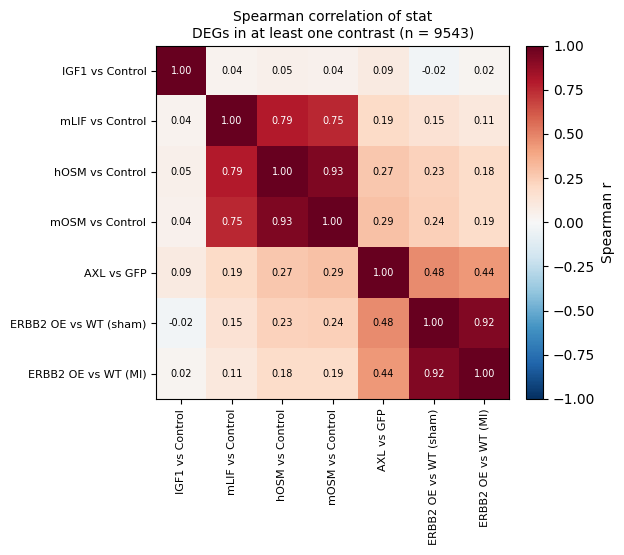

In [7]:
deg_any_genes = shared_genes[is_deg.loc[shared_genes].any(axis=1)]
print(f'{len(deg_any_genes)} shared genes are DEGs in at least one contrast')

corr_deg = value_df.loc[deg_any_genes].corr(method=corr_method)
corr_deg.to_csv(f'{results_dir}/correlation_{corr_method}_{corr_value}_degs_any_contrast.csv')

plot_matrix_heatmap(
    corr_deg,
    title=f'{corr_method.capitalize()} correlation of {corr_value}\nDEGs in at least one contrast (n = {len(deg_any_genes)})',
    fname=f'correlation_{corr_method}_{corr_value}_degs_any_contrast',
    cbar_label=f'{corr_method.capitalize()} r',
    order=contrast_order,
)

## Direction-aware DEG overlap

### All pairs of contrasts
For each pair, only genes tested in both contrasts are used.

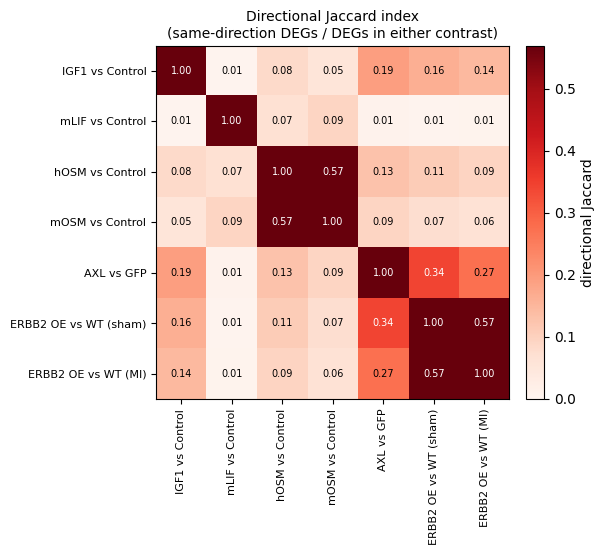

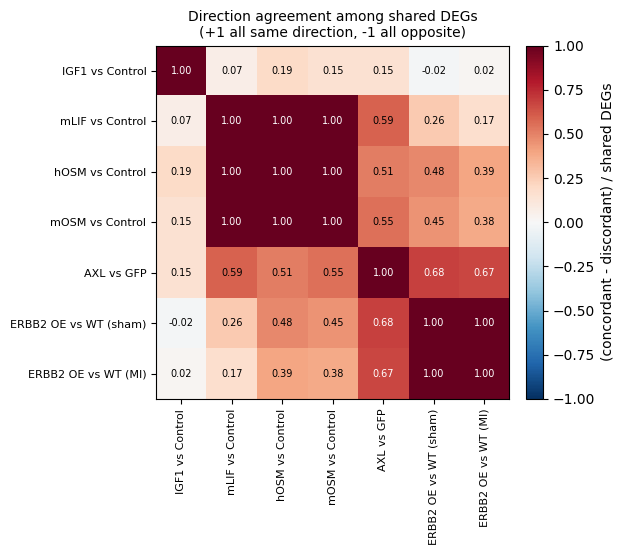

In [8]:
def overlap_stats(a, b):
    d = deg_direction[[a, b]].dropna()   # genes tested in both contrasts
    x, y = d[a], d[b]
    res = {
        'contrast_a': a, 'contrast_b': b, 'background': len(d),
        'DEGs_a': int((x != 0).sum()), 'DEGs_b': int((y != 0).sum()),
        'DEGs_union': int(((x != 0) | (y != 0)).sum()),
        'up_up': int(((x == 1) & (y == 1)).sum()),
        'down_down': int(((x == -1) & (y == -1)).sum()),
        'up_down': int(((x == 1) & (y == -1)).sum()),
        'down_up': int(((x == -1) & (y == 1)).sum()),
    }
    concordant = res['up_up'] + res['down_down']
    discordant = res['up_down'] + res['down_up']
    res['concordant'], res['discordant'] = concordant, discordant
    res['directional_jaccard'] = concordant / res['DEGs_union'] if res['DEGs_union'] else np.nan
    res['direction_agreement'] = (concordant - discordant) / (concordant + discordant) if concordant + discordant else np.nan

    # one-sided Fisher's exact test: are shared up (or down) DEGs more frequent than expected by chance?
    for direction, val in [('up', 1), ('down', -1)]:
        table = [[((x == val) & (y == val)).sum(), ((x == val) & (y != val)).sum()],
                 [((x != val) & (y == val)).sum(), ((x != val) & (y != val)).sum()]]
        odds, p = fisher_exact(table, alternative='greater')
        res[f'{direction}_odds_ratio'], res[f'{direction}_fisher_p'] = odds, p
    return res

overlap_df = pd.DataFrame([overlap_stats(a, b) for a, b in combinations(labels, 2)])
overlap_df.to_csv(f'{results_dir}/deg_overlap_all_pairs.csv', index=False)


def pair_matrix(col, diagonal):
    mat = pd.DataFrame(np.nan, index=labels, columns=labels)
    for _, r in overlap_df.iterrows():
        mat.loc[r.contrast_a, r.contrast_b] = r[col]
        mat.loc[r.contrast_b, r.contrast_a] = r[col]
    for l in labels:
        mat.loc[l, l] = diagonal
    return mat

jaccard_mat = pair_matrix('directional_jaccard', 1.0)
agreement_mat = pair_matrix('direction_agreement', 1.0)

offdiag_max = jaccard_mat.where(~np.eye(len(labels), dtype=bool)).max().max()
plot_matrix_heatmap(
    jaccard_mat,
    title='Directional Jaccard index\n(same-direction DEGs / DEGs in either contrast)',
    fname='deg_overlap_directional_jaccard',
    vmin=0, vmax=offdiag_max, cmap='Reds', cbar_label='directional Jaccard',
    order=contrast_order,
)
plot_matrix_heatmap(
    agreement_mat,
    title='Direction agreement among shared DEGs\n(+1 all same direction, -1 all opposite)',
    fname='deg_overlap_direction_agreement',
    cbar_label='(concordant - discordant) / shared DEGs',
    order=contrast_order,
)

### AXL vs each comparator: quadrant counts

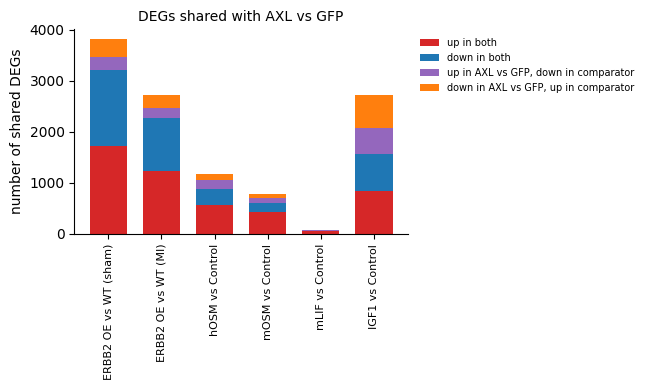

,background,DEGs_a,DEGs_b,up_up,down_down,up_down,down_up,directional_jaccard,direction_agreement,up_odds_ratio,up_fisher_p,down_odds_ratio,down_fisher_p
contrast_b,,,,,,,,,,,,,
ERBB2 OE vs WT (sham),13848,6561,6643,1726,1480,252,358,0.341500,0.680294,4.357171,3.478735e-266,5.587227,1.475669e-313
ERBB2 OE vs WT (MI),13848,6561,4527,1229,1045,186,261,0.271782,0.671444,4.087633,3.048613e-195,4.841948,1.272952e-210
hOSM vs Control,12539,6278,1841,567,316,177,106,0.126996,0.514580,3.677791,1.937966e-86,2.323605,5.834454e-27
mOSM vs Control,12539,6278,1218,425,189,95,81,0.091560,0.554430,3.858469,6.102956e-70,2.393138,4.291376e-18
mLIF vs Control,12539,6278,127,58,8,8,9,0.010440,0.590361,3.566382,1.834943e-10,1.718758,1.568093e-01
IGF1 vs Control,12375,6018,4909,847,723,496,662,0.191487,0.151026,1.411242,5.694986e-13,1.895427,6.630965e-34


In [9]:
comparators = [l for l in labels if l != reference]
ref_overlap = pd.DataFrame([overlap_stats(reference, c) for c in comparators]).set_index('contrast_b')
ref_overlap.to_csv(f'{results_dir}/deg_overlap_{slug(reference)}_vs_comparators.csv')

quadrants = ['up_up', 'down_down', 'up_down', 'down_up']
quad_colors = {'up_up': '#d62728', 'down_down': '#1f77b4', 'up_down': '#9467bd', 'down_up': '#ff7f0e'}
quad_names = {
    'up_up': 'up in both', 'down_down': 'down in both',
    'up_down': f'up in {reference}, down in comparator', 'down_up': f'down in {reference}, up in comparator',
}

fig, ax = plt.subplots(figsize=(0.6 * len(comparators) + 3, 4))
bottom = np.zeros(len(comparators))
for q in quadrants:
    vals = ref_overlap[q].values
    ax.bar(range(len(comparators)), vals, bottom=bottom, color=quad_colors[q], label=quad_names[q], width=0.7)
    bottom += vals
ax.set_xticks(range(len(comparators)))
ax.set_xticklabels(comparators, rotation=90, ha='center', fontsize=8)
ax.set_ylabel('number of shared DEGs')
ax.set_title(f'DEGs shared with {reference}', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
fig.tight_layout()
fig.savefig(f'{figures_dir}/deg_overlap_{slug(reference)}_quadrant_counts.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{figures_dir}/deg_overlap_{slug(reference)}_quadrant_counts.pdf', bbox_inches='tight')
plt.show()

ref_overlap[['background', 'DEGs_a', 'DEGs_b', 'up_up', 'down_down', 'up_down', 'down_up',
             'directional_jaccard', 'direction_agreement',
             'up_odds_ratio', 'up_fisher_p', 'down_odds_ratio', 'down_fisher_p']]

### AXL vs each comparator: log2FC scatter plots and gene lists
Each point is a gene tested in both contrasts, coloured by DEG quadrant. The full per-gene tables (log2FC, padj and quadrant in both contrasts) are written to `results/contrast_comparison/` for follow-up.

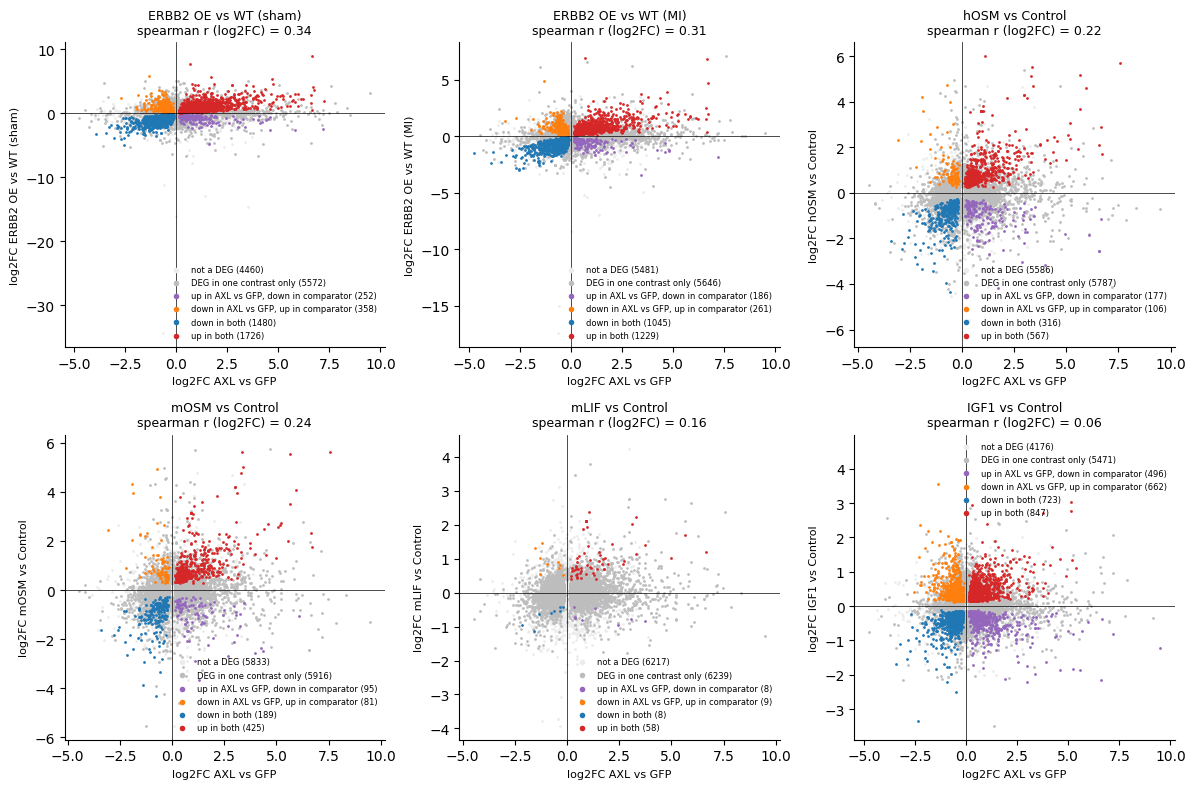

In [10]:
scatter_colors = {**quad_colors, 'one_only': '#bdbdbd', 'neither': '#ececec'}
scatter_names = {**quad_names, 'one_only': 'DEG in one contrast only', 'neither': 'not a DEG'}
plot_order = ['neither', 'one_only', 'up_down', 'down_up', 'down_down', 'up_up']   # coloured points on top

n_cols = 3
n_rows = int(np.ceil(len(comparators) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)

for ax, comp in zip(axes.flat, comparators):
    d = deg_direction[[reference, comp]].dropna()
    x, y = d[reference], d[comp]
    quadrant = pd.Series(np.select(
        [(x == 1) & (y == 1), (x == -1) & (y == -1), (x == 1) & (y == -1), (x == -1) & (y == 1), (x != 0) | (y != 0)],
        ['up_up', 'down_down', 'up_down', 'down_up', 'one_only'], default='neither'), index=d.index)

    genes_out = pd.DataFrame({
        f'log2FC {reference}': lfc_df.loc[d.index, reference], f'padj {reference}': padj_df.loc[d.index, reference],
        f'log2FC {comp}': lfc_df.loc[d.index, comp], f'padj {comp}': padj_df.loc[d.index, comp],
        'quadrant': quadrant,
    })
    genes_out.sort_values('quadrant').to_csv(f'{results_dir}/deg_overlap_{slug(reference)}_vs_{slug(comp)}_genes.csv')

    for q in plot_order:
        g = quadrant.index[quadrant == q]
        ax.scatter(lfc_df.loc[g, reference], lfc_df.loc[g, comp], s=4, linewidths=0,
                   color=scatter_colors[q], label=f'{scatter_names[q]} ({len(g)})', rasterized=True)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    r = lfc_df.loc[d.index, reference].corr(lfc_df.loc[d.index, comp], method=corr_method)
    ax.set_title(f'{comp}\n{corr_method} r (log2FC) = {r:.2f}', fontsize=9)
    ax.set_xlabel(f'log2FC {reference}', fontsize=8)
    ax.set_ylabel(f'log2FC {comp}', fontsize=8)
    ax.legend(frameon=False, fontsize=6, markerscale=2, loc='best')
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes.flat[len(comparators):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(f'{figures_dir}/deg_overlap_{slug(reference)}_scatter.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{figures_dir}/deg_overlap_{slug(reference)}_scatter.pdf', bbox_inches='tight')
plt.show()